# Live Coding: Clustering avanzado y reglas de asociación en retail

Dataset: **Online Retail / Online Retail II** (UCI / Kaggle).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Ruta base ABSOLUTA de tu proyecto
BASE_DIR = r"D:\000_ANALISTA DATOS , TALENTO DIGITAL\Bootcamp-main\Modulo7\Leccion1"

# Carpeta de figuras dentro de esa ruta
FIG_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plt.style.use("seaborn-v0_8")

## 1. Carga y preparación de datos

Pasos:
1. Cargar el CSV de Online Retail II.
2. Limpiar nulos y devoluciones.
3. Filtrar un país.
4. Crear variables agregadas por cliente.
5. Asegurar que las columnas sean numéricas y estandarizarlas.


In [2]:
# 1.1 Carga del dataset (ruta absoluta)

file_path = os.path.join(BASE_DIR, "online_retail_II.csv")
print("Usando archivo:", file_path)

df = pd.read_csv(file_path, encoding="ISO-8859-1")
print("Shape original:", df.shape)
df.head()

Usando archivo: D:\000_ANALISTA DATOS , TALENTO DIGITAL\Bootcamp-main\Modulo7\Leccion1\online_retail_II.csv
Shape original: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 7:45,"6,95",13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 7:45,"6,75",13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 7:45,"6,75",13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 7:45,"2,1",13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 7:45,"1,25",13085.0,United Kingdom


In [3]:
# 1.2 Limpieza básica: nulos y devoluciones

df = df.dropna(subset=["Description", "Customer ID"])
df = df[~df["Invoice"].astype(str).str.startswith("C")]
print("Shape tras limpiar nulos y devoluciones:", df.shape)

df.head()

Shape tras limpiar nulos y devoluciones: (407695, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 7:45,"6,95",13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 7:45,"6,75",13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 7:45,"6,75",13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 7:45,"2,1",13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 7:45,"1,25",13085.0,United Kingdom


In [4]:
# 1.3 Filtrado por país

print("Países disponibles:", df["Country"].unique())
country_filter = "United Kingdom"  # puedes cambiarlo en vivo

df = df[df["Country"] == country_filter]
print(f"Shape tras filtrar país ({country_filter}):", df.shape)

df.head()

Países disponibles: ['United Kingdom' 'France' 'USA' 'Belgium' 'Australia' 'EIRE' 'Germany'
 'Portugal' 'Denmark' 'Netherlands' 'Poland' 'Channel Islands' 'Spain'
 'Cyprus' 'Greece' 'Norway' 'Austria' 'Sweden' 'United Arab Emirates'
 'Finland' 'Italy' 'Switzerland' 'Japan' 'Unspecified' 'Nigeria' 'Malta'
 'RSA' 'Singapore' 'Bahrain' 'Thailand' 'Israel' 'Lithuania' 'West Indies'
 'Korea' 'Brazil' 'Canada' 'Iceland']
Shape tras filtrar país (United Kingdom): (370951, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 7:45,"6,95",13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 7:45,"6,75",13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 7:45,"6,75",13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 7:45,"2,1",13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 7:45,"1,25",13085.0,United Kingdom


In [5]:
# 1.4 Total por línea y agregado por cliente

df["TotalPrice"] = df["Quantity"] * df["Price"]

customer_df = (
    df.groupby("Customer ID")
      .agg(
          NumInvoices=("Invoice", "nunique"),
          NumItems=("Quantity", "sum"),
          TotalSpent=("TotalPrice", "sum")
      )
      .reset_index()
)

print("Clientes únicos (antes de forzar tipos):", customer_df.shape[0])
customer_df.head()

Clientes únicos (antes de forzar tipos): 3971


,Customer ID,NumInvoices,NumItems,TotalSpent
0,12346.0,11,70,"4,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54..."
1,12608.0,1,323,"2,952,952,952,952,952,952,952,952,952,952,952,..."
2,12745.0,2,467,"1,061,061,061,061,061,061,061,061,061,061,061,..."
3,12746.0,1,97,"1,251,251,251,251,251,251,251,251,251,251,251,..."
4,12747.0,16,1483,"2,952,952,952,952,952,952,952,952,952,952,952,..."


In [6]:
# 1.5 Corrección de tipos y estandarización

for col in ["NumInvoices", "NumItems", "TotalSpent"]:
    customer_df[col] = (
        customer_df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    customer_df[col] = pd.to_numeric(customer_df[col], errors="coerce")

before = customer_df.shape[0]
customer_df = customer_df.dropna(subset=["NumInvoices", "NumItems", "TotalSpent"])
after = customer_df.shape[0]
print(f"Clientes antes: {before}, después de limpiar tipos: {after}")

features = ["NumInvoices", "NumItems", "TotalSpent"]
scaler = StandardScaler()
X = scaler.fit_transform(customer_df[features])
print("Shape de X para clustering:", X.shape)

Clientes antes: 3971, después de limpiar tipos: 18
Shape de X para clustering: (18, 3)


## 2. Aplicación de DBSCAN

1. Graficamos la curva k-dist para elegir `eps`.
2. Aplicamos DBSCAN.
3. Revisamos tamaños de cluster (incluyendo ruido).


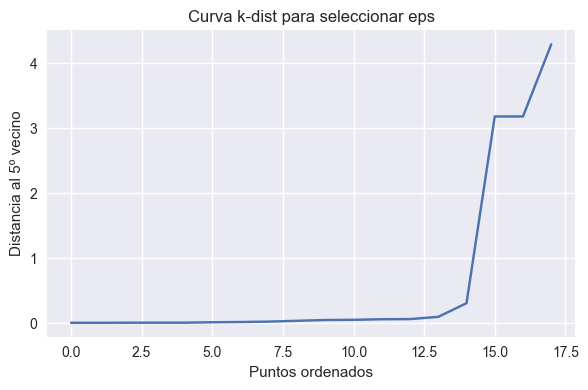

In [7]:
# 2.1 Curva k-dist

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, _ = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(distances)
plt.ylabel("Distancia al 5º vecino")
plt.xlabel("Puntos ordenados")
plt.title("Curva k-dist para seleccionar eps")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_dbscan_kdist_nb.png"), dpi=150)
plt.show()

In [8]:
# 2.2 Aplicación de DBSCAN

eps = 0.8
min_samples = 10

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X)

customer_df["DBSCAN_cluster"] = labels_dbscan

unique, counts = np.unique(labels_dbscan, return_counts=True)
cluster_info = dict(zip(unique, counts))
cluster_info

{np.int64(-1): np.int64(3), np.int64(0): np.int64(15)}

## 3. Visualización 2D con t-SNE

Ajustamos automáticamente la `perplexity` para que sea válida (`< n_samples`).


n_samples = 18, usando perplexity = 9


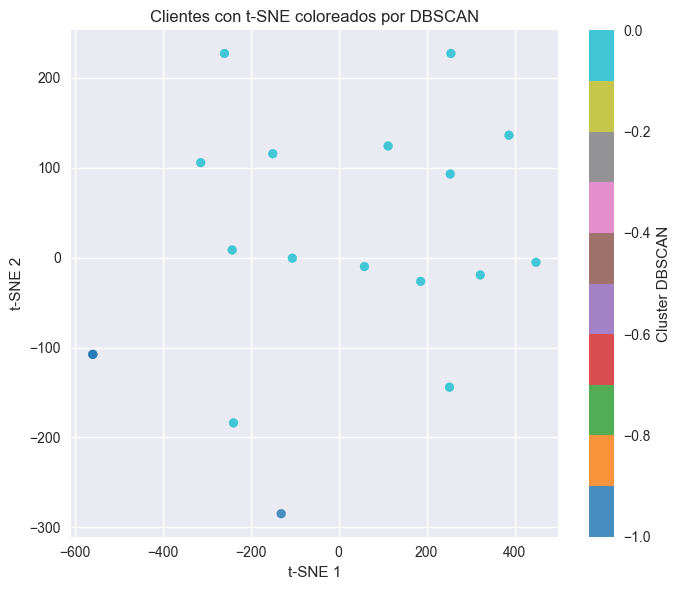

In [9]:
# 3.1 t-SNE adaptativo

n_samples = X.shape[0]
if n_samples <= 10:
    perplexity = max(2, n_samples // 2)
else:
    perplexity = min(30, n_samples // 2)

print(f"n_samples = {n_samples}, usando perplexity = {perplexity}")

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=customer_df["DBSCAN_cluster"],
    cmap="tab10",
    s=40,
    alpha=0.8,
)
plt.colorbar(scatter, label="Cluster DBSCAN")
plt.title("Clientes con t-SNE coloreados por DBSCAN")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_tsne_dbscan_nb.png"), dpi=150)
plt.show()

## 4. Clustering jerárquico y dendrograma

Muestreamos para el dendrograma y luego asignamos clusters jerárquicos.


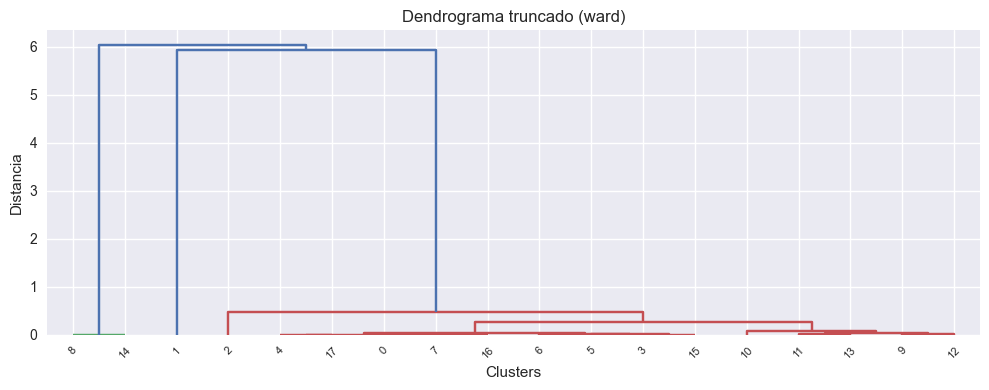

In [10]:
# 4.1 Dendrograma

sample_size = min(300, X.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=sample_size, replace=False)
X_sample = X[sample_idx]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(10, 4))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=45.0,
    leaf_font_size=8.0,
)
plt.title("Dendrograma truncado (ward)")
plt.xlabel("Clusters")
plt.ylabel("Distancia")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_dendrograma_nb.png"), dpi=150)
plt.show()

In [11]:
# 4.2 Clustering jerárquico

n_clusters = 4
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
labels_hier = agg.fit_predict(X)

customer_df["HIER_cluster"] = labels_hier

unique_h, counts_h = np.unique(labels_hier, return_counts=True)
cluster_info_h = dict(zip(unique_h, counts_h))
cluster_info_h

{np.int64(0): np.int64(14),
 np.int64(1): np.int64(2),
 np.int64(2): np.int64(1),
 np.int64(3): np.int64(1)}

## 5. Apriori (mlxtend)

Construimos transacciones, hacemos one‑hot y extraemos itemsets frecuentes.


In [12]:
# 5.1 Lista de transacciones

basket_series = df.groupby("Invoice")["Description"].apply(list)
transactions = basket_series.tolist()

len(transactions), transactions[:3]

(17614,
 [['15CM CHRISTMAS GLASS BALL 20 LIGHTS',
   'PINK CHERRY LIGHTS',
   ' WHITE CHERRY LIGHTS',
   'RECORD FRAME 7" SINGLE SIZE ',
   'STRAWBERRY CERAMIC TRINKET BOX',
   'PINK DOUGHNUT TRINKET POT ',
   'SAVE THE PLANET MUG',
   'FANCY FONT HOME SWEET HOME DOORMAT'],
  ['CAT BOWL ',
   'DOG BOWL , CHASING BALL DESIGN',
   'HEART MEASURING SPOONS LARGE',
   'LUNCHBOX WITH CUTLERY FAIRY CAKES '],
  ['DOOR MAT BLACK FLOCK ',
   'LOVE BUILDING BLOCK WORD',
   'HOME BUILDING BLOCK WORD',
   'ASSORTED COLOUR BIRD ORNAMENT',
   ' PEACE WOODEN BLOCK LETTERS',
   'CHRISTMAS CRAFT WHITE FAIRY ',
   'HEART IVORY TRELLIS LARGE',
   'HEART FILIGREE DOVE LARGE',
   'FULL ENGLISH BREAKFAST PLATE',
   'PIZZA PLATE IN BOX',
   'BLACK DINER WALL CLOCK',
   'SET OF 3 BLACK FLYING DUCKS',
   'AREA PATROLLED METAL SIGN',
   'PLEASE ONE PERSON  METAL SIGN',
   'BATH BUILDING BLOCK WORD',
   'CLASSIC WHITE FRAME',
   'SMALL MARSHMALLOWS PINK BOWL',
   'BISCUITS SMALL BOWL LIGHT BLUE',
   'SCOTTIE DOG 

In [13]:
# 5.2 One-hot encoding y Apriori

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket_df = pd.DataFrame(te_array, columns=te.columns_)
print("Shape one-hot:", basket_df.shape)

min_support = 0.02
frequent_itemsets = apriori(
    basket_df,
    min_support=min_support,
    use_colnames=True,
)
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False)
print("Itemsets frecuentes:", frequent_itemsets.shape[0])

frequent_itemsets.head(10)

Shape one-hot: (17614, 4415)
Itemsets frecuentes: 203


,support,itemsets
168,0.165777,(WHITE HANGING HEART T-LIGHT HOLDER)
135,0.085954,(REGENCY CAKESTAND 3 TIER)
6,0.071534,(ASSORTED COLOUR BIRD ORNAMENT)
154,0.070285,(STRAWBERRY CERAMIC TRINKET BOX)
59,0.064551,(HOME BUILDING BLOCK WORD)
138,0.058817,(REX CASH+CARRY JUMBO SHOPPER)
3,0.058022,(60 TEATIME FAIRY CAKE CASES)
102,0.056659,(PACK OF 72 RETRO SPOT CAKE CASES)
70,0.056149,(JUMBO BAG RED RETROSPOT)
57,0.055921,(HEART OF WICKER LARGE)


## 6. Reglas de asociación y filtrado

Generamos reglas y filtramos por soporte, confianza y lift.


In [14]:
# 6.1 Generación y filtrado de reglas

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3,
)
print("Reglas totales (sin filtro):", rules.shape[0])

support_threshold = 0.02
confidence_threshold = 0.4
lift_threshold = 1.2

rules_filtered = rules[
    (rules["support"] >= support_threshold)
    & (rules["confidence"] >= confidence_threshold)
    & (rules["lift"] >= lift_threshold)
].sort_values("lift", ascending=False)

print("Reglas tras filtrado:", rules_filtered.shape[0])

rules_filtered[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

Reglas totales (sin filtro): 33
Reglas tras filtrado: 25


,antecedents,consequents,support,confidence,lift
3,(WOODEN PICTURE FRAME WHITE FINISH),(WOODEN FRAME ANTIQUE WHITE ),0.030828,0.684741,12.307180
4,(WOODEN FRAME ANTIQUE WHITE ),(WOODEN PICTURE FRAME WHITE FINISH),0.030828,0.554082,12.307180
2,(STRAWBERRY CERAMIC TRINKET BOX),(SWEETHEART CERAMIC TRINKET BOX),0.033099,0.470921,10.857068
1,(SWEETHEART CERAMIC TRINKET BOX),(STRAWBERRY CERAMIC TRINKET BOX),0.033099,0.763089,10.857068
26,(HOT WATER BOTTLE TEA AND SYMPATHY),(CHOCOLATE HOT WATER BOTTLE),0.020722,0.464968,10.636297
25,(CHOCOLATE HOT WATER BOTTLE),(HOT WATER BOTTLE TEA AND SYMPATHY),0.020722,0.474026,10.636297
8,(HEART OF WICKER LARGE),(HEART OF WICKER SMALL),0.027592,0.493401,10.140917
7,(HEART OF WICKER SMALL),(HEART OF WICKER LARGE),0.027592,0.567095,10.140917
12,(LUNCH BAG SUKI DESIGN ),(LUNCH BAG SPACEBOY DESIGN ),0.023504,0.475316,10.123593
13,(LUNCH BAG SPACEBOY DESIGN ),(LUNCH BAG SUKI DESIGN ),0.023504,0.500605,10.123593


## 7. Visualización soporte / confianza / lift

Scatterplot donde cada punto es una regla.


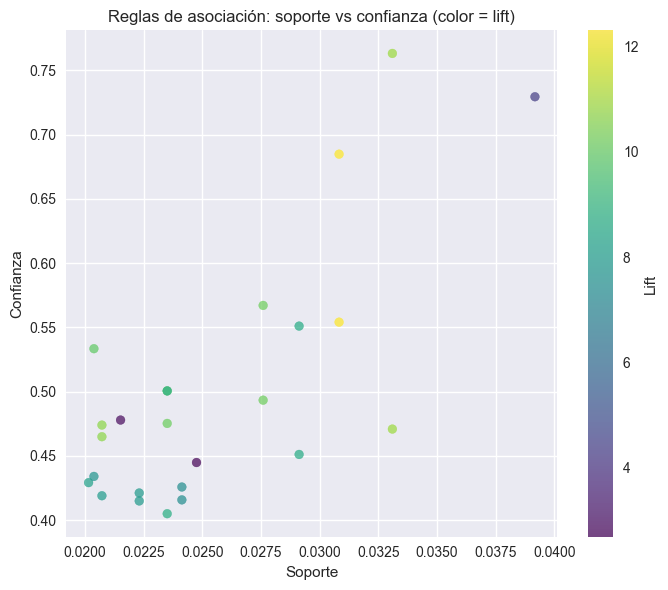

In [15]:
# 7.1 Scatter de reglas

if rules_filtered.empty:
    print("No hay reglas que cumplan los umbrales establecidos.")
else:
    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(
        rules_filtered["support"],
        rules_filtered["confidence"],
        c=rules_filtered["lift"],
        cmap="viridis",
        s=40,
        alpha=0.7,
    )
    plt.colorbar(scatter, label="Lift")
    plt.xlabel("Soporte")
    plt.ylabel("Confianza")
    plt.title("Reglas de asociación: soporte vs confianza (color = lift)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "04_reglas_scatter_nb.png"), dpi=150)
    plt.show()